# Assessment 1: Data Preprocessing & Exploration

### Dataset
U.S. Airline On-Time Performance 1987–2020 (2M row sample, BTS)

### Business Question
What factors are most predictive of flight arrival delays, and how have delay patterns shifted across airlines, airports, and seasons over the 33-year period from 1987 to 2020?

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bi.config import (
    RAW_CSV, CLEANED_PARQUET, OUTPUT_DIR, CSV_ENCODING,
    DROP_COLS, CORE_COLS, INT_COLS, DOUBLE_COLS,
    DELAY_MIN_MINUTES, DELAY_MAX_MINUTES, MIN_CARRIER_FLIGHTS,
    FIGURE_DPI, FIGURE_SIZE, COLOR_PRIMARY, COLOR_DELAY, COLOR_GOOD,
    TARGET_COL, MONTH_TO_SEASON, DOW_LABELS, MONTH_LABELS,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = FIGURE_SIZE
sns.set_theme(style='whitegrid')

print(f'Data file exists : {RAW_CSV.exists()}')
print(f'Output dir       : {OUTPUT_DIR}')
print(f'CSV encoding     : {CSV_ENCODING}')

Data file exists : True
Output dir       : C:\Projects\bi\output
CSV encoding     : latin-1


## 1. Load Data

In [2]:
df = pd.read_csv(RAW_CSV, low_memory=False, encoding=CSV_ENCODING)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Shape: 2,000,000 rows × 109 columns


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,...,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum
0,1998,1,1,2,5,1998-01-02,NW,19386,NW,N297US,675,13487,1348701,31650,MSP,"Minneapolis, MN",MN,27.00,Minnesota,63,14869,1486902,34614,SLC,"Salt Lake City, UT",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009,2,5,28,4,2009-05-28,FL,20437,FL,N946AT,671,13342,1334202,33342,MKE,"Milwaukee, WI",WI,55.00,Wisconsin,45,13204,1320401,31454,MCO,"Orlando, FL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013,2,6,29,6,2013-06-29,MQ,20398,MQ,N665MQ,3297,11921,1192102,31921,GJT,"Grand Junction, CO",CO,8.00,Colorado,82,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial Data Audit

In [3]:
df.dtypes.to_frame('dtype').T

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,...,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum
dtype,int64,int64,int64,int64,int64,str,str,int64,str,str,int64,int64,int64,int64,str,str,str,float64,str,int64,int64,int64,int64,str,str,...,str,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


In [4]:
missing = pd.DataFrame({
    'missing':     df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
}).sort_values('missing_pct', ascending=False)

missing[missing.missing > 0]

,missing,missing_pct
Div4WheelsOn,2000000,100.00
Div4TotalGTime,2000000,100.00
Div4LongestGTime,2000000,100.00
Div4WheelsOff,2000000,100.00
Div4TailNum,2000000,100.00
...,...,...
OriginStateFips,646,0.03
DestState,594,0.03
DestStateName,594,0.03
DestStateFips,594,0.03


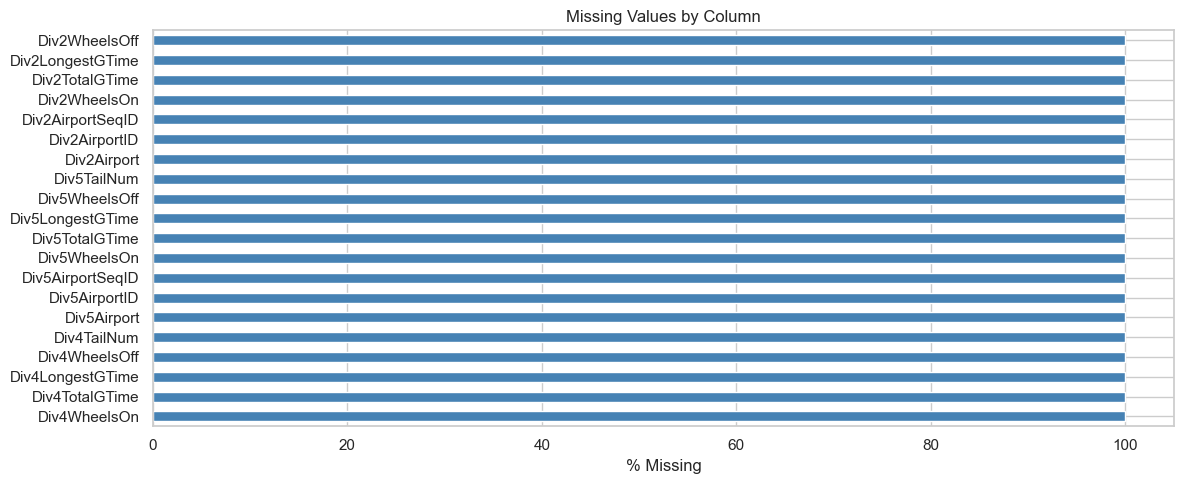

In [5]:
top_missing = missing[missing.missing_pct > 0].head(20)
top_missing['missing_pct'].plot(kind='barh', color=COLOR_PRIMARY)
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'missing_values.png', dpi=FIGURE_DPI)
plt.show()

## 3. Preprocessing

In [6]:
# DECISION 1: Drop redundant / all-null columns
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f'After dropping redundant columns: {df.shape[1]} columns remain')

After dropping redundant columns: 77 columns remain


In [7]:
# DECISION 2: Drop rows missing core identifiers
before = len(df)
df.dropna(subset=CORE_COLS, inplace=True)
print(f'Dropped {before - len(df):,} rows missing core identifiers')

Dropped 0 rows missing core identifiers


In [8]:
# DECISION 3: Remove physically impossible delay values
before = len(df)
df = df[
    (df['ArrDelay'].isna() | df['ArrDelay'].between(DELAY_MIN_MINUTES, DELAY_MAX_MINUTES)) &
    (df['DepDelay'].isna() | df['DepDelay'].between(DELAY_MIN_MINUTES, DELAY_MAX_MINUTES))
]
print(f'Removed {before - len(df):,} rows with impossible delay values')

Removed 10 rows with impossible delay values


In [9]:
# DECISION 4: Cast column types
for col in INT_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
print('Types corrected.')

Types corrected.


In [10]:
# DECISION 5: Feature engineering
# ArrDel15 is null for cancelled flights — treat as not delayed (handled by Cancelled column)
df['Decade']    = (df['Year'] // 10 * 10).astype('Int64')
df['Season']    = df['Month'].map(MONTH_TO_SEASON)
df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)
df['DepHour']   = (df['CRSDepTime'] // 100).astype('Int64')
df[TARGET_COL]  = (df['ArrDel15'].fillna(0) == 1).astype(int)

print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Final shape: 1,999,990 rows × 82 columns


## 4. Exploratory Data Analysis

In [11]:
df[['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'TaxiOut', 'TaxiIn']].describe().round(2)

,ArrDelay,DepDelay,Distance,AirTime,TaxiOut,TaxiIn
count,1958912.00,1963922.00,1999990.00,1580643.00,1584350.00,1582145.00
mean,6.20,8.58,733.49,105.95,15.81,6.71
std,34.69,32.57,568.49,68.59,10.24,7.95
min,-94.00,-82.00,11.00,-703.00,0.00,0.00
25%,-10.00,-3.00,325.00,56.00,10.00,4.00
50%,-1.00,0.00,580.00,87.00,13.00,5.00
75%,10.00,7.00,967.00,135.00,18.00,8.00
max,1430.00,1439.00,5095.00,686.00,1412.00,1439.00


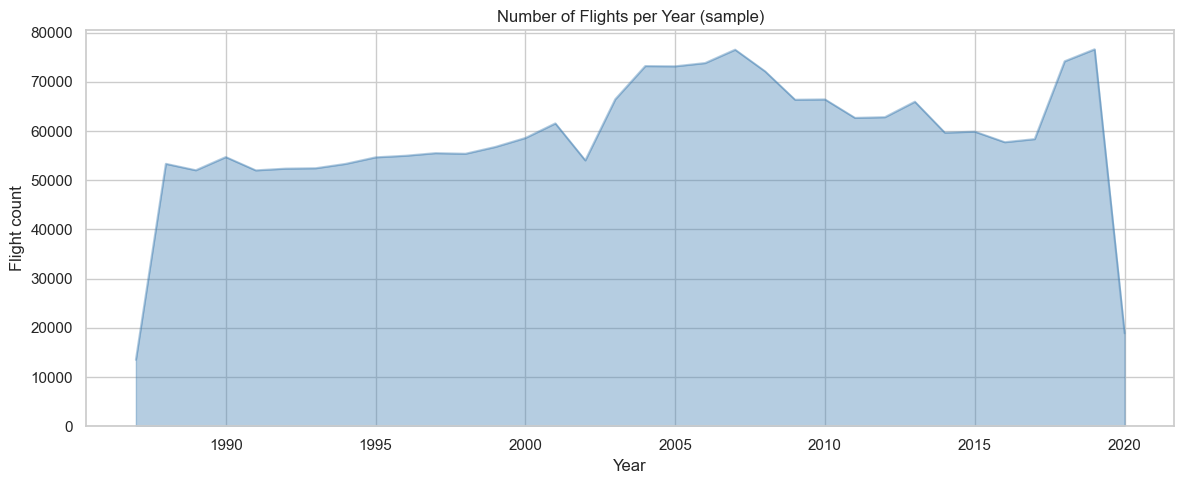

In [12]:
# Flight volume over time
df.groupby('Year').size().plot(kind='area', alpha=0.4, color=COLOR_PRIMARY)
plt.title('Number of Flights per Year (sample)')
plt.ylabel('Flight count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'flights_per_year.png', dpi=FIGURE_DPI)
plt.show()

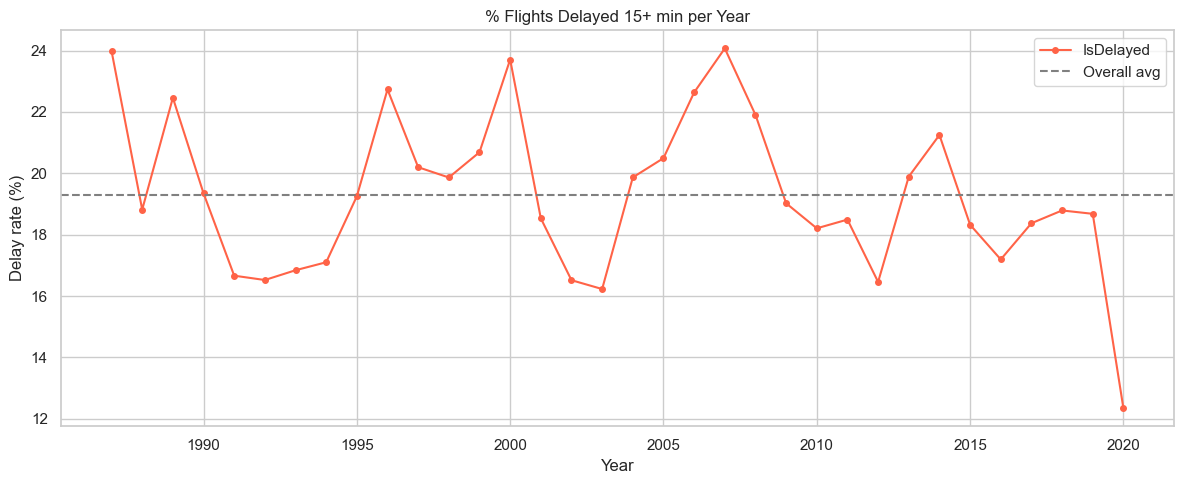

In [13]:
# Delay rate over time
delay_rate = df.groupby('Year')[TARGET_COL].mean() * 100
delay_rate.plot(marker='o', ms=4, color=COLOR_DELAY)
plt.axhline(delay_rate.mean(), ls='--', color='gray', label='Overall avg')
plt.title('% Flights Delayed 15+ min per Year')
plt.ylabel('Delay rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delay_rate_by_year.png', dpi=FIGURE_DPI)
plt.show()

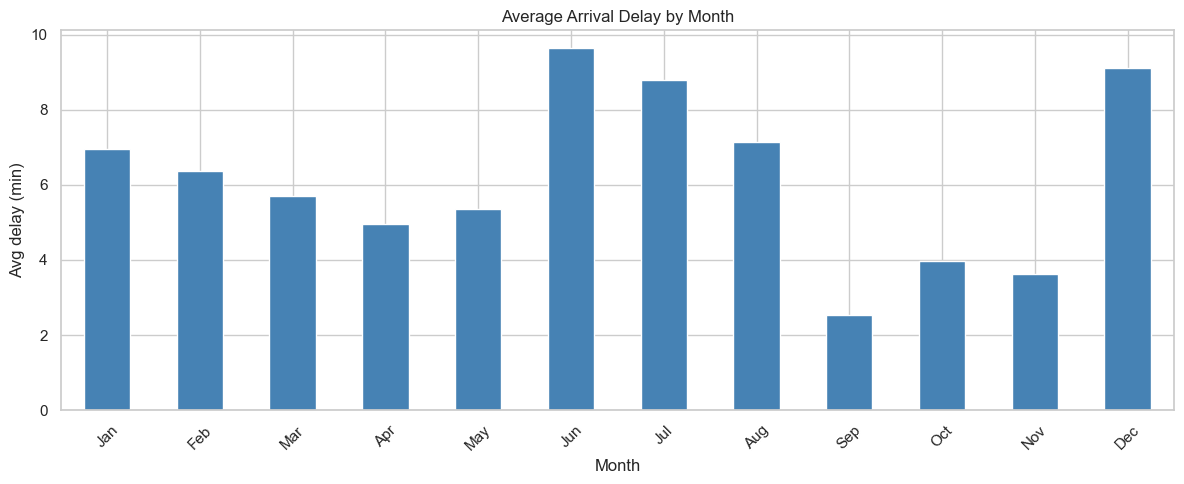

In [14]:
# Seasonality — delay by month
df.groupby('Month')['ArrDelay'].mean().plot(kind='bar', color=COLOR_PRIMARY)
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg delay (min)')
plt.xticks(range(12), MONTH_LABELS, rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delay_by_month.png', dpi=FIGURE_DPI)
plt.show()

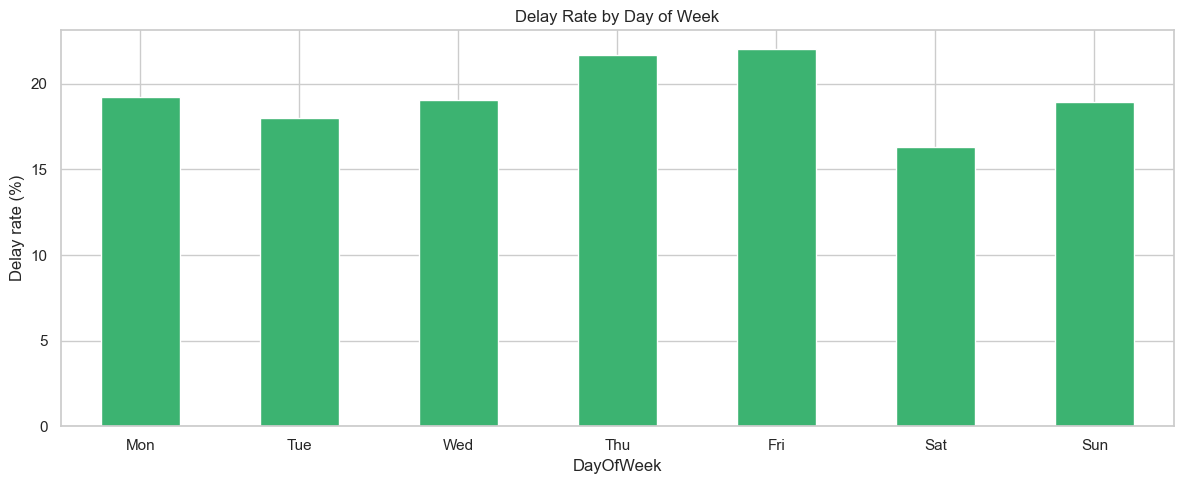

In [15]:
# Delay by day of week
dow = (df.groupby('DayOfWeek')[TARGET_COL].mean() * 100).rename(index=DOW_LABELS)
dow.plot(kind='bar', color=COLOR_GOOD)
plt.title('Delay Rate by Day of Week')
plt.ylabel('Delay rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delay_by_dow.png', dpi=FIGURE_DPI)
plt.show()

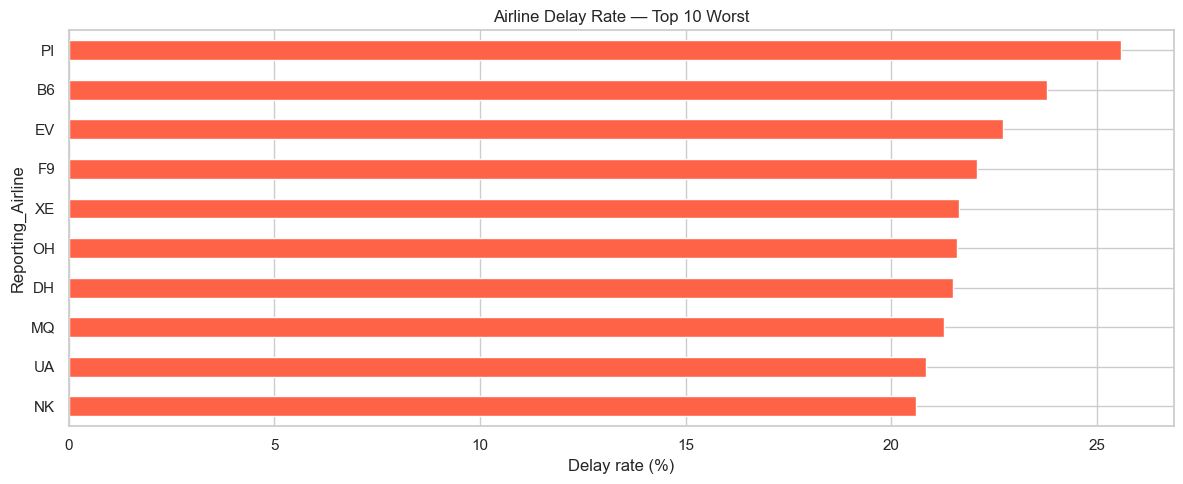

In [16]:
# Airline delay rates
airline = (
    df.groupby('Reporting_Airline')
    .agg(flights=(TARGET_COL, 'count'), delay_rate=(TARGET_COL, 'mean'))
    .query(f'flights > {MIN_CARRIER_FLIGHTS}')
    .assign(delay_rate=lambda x: x.delay_rate * 100)
    .sort_values('delay_rate')
    .tail(10)
)
airline['delay_rate'].plot(kind='barh', color=COLOR_DELAY)
plt.title('Airline Delay Rate — Top 10 Worst')
plt.xlabel('Delay rate (%)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'delay_by_airline.png', dpi=FIGURE_DPI)
plt.show()

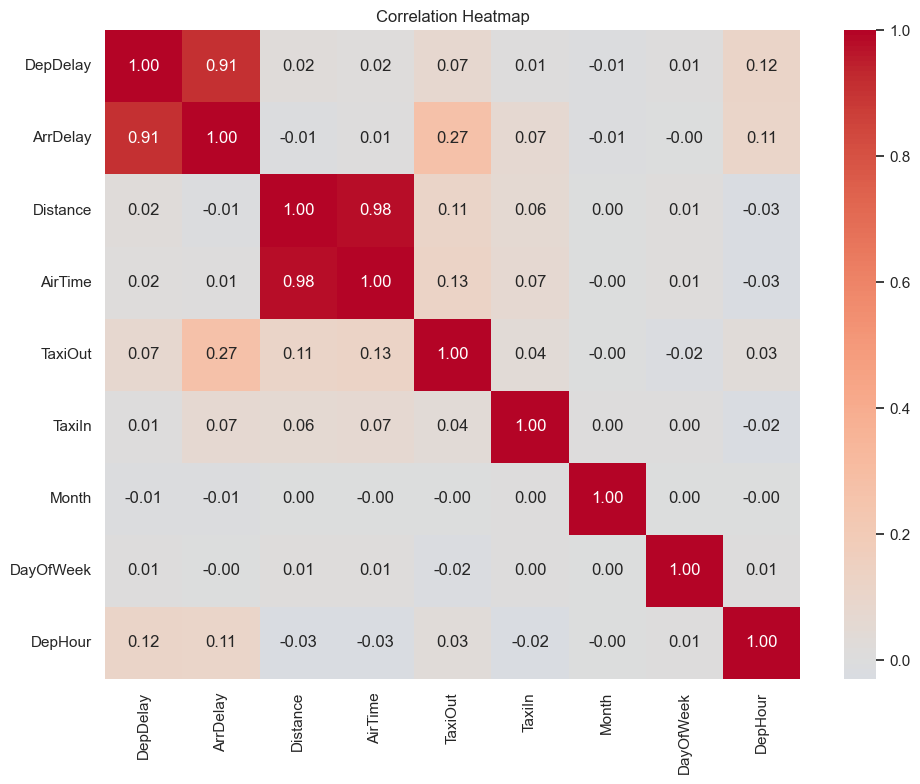

In [17]:
# Correlation heatmap
numeric_cols = ['DepDelay', 'ArrDelay', 'Distance', 'AirTime',
                'TaxiOut', 'TaxiIn', 'Month', 'DayOfWeek', 'DepHour']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=FIGURE_DPI)
plt.show()

## 5. Save Cleaned Dataset

In [19]:
df.to_parquet(CLEANED_PARQUET, index=False)
size_mb = CLEANED_PARQUET.stat().st_size / 1024 / 1024
print(f'Saved: {CLEANED_PARQUET.name} ({size_mb:.1f} MB)')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Saved: airline_cleaned.parquet (87.0 MB)
Final shape: 1,999,990 rows x 82 columns


## 6. Preprocessing Decisions Summary

| # | Decision | What | Why |
|---|----------|------|-----|
| 1 | Drop redundant columns | Airport seq IDs, WAC codes, Div3-5 | 100% null or duplicated by simpler columns |
| 2 | Drop rows missing core fields | Year, Month, Origin, Dest, Airline | Cannot assign a flight to any meaningful record without these |
| 3 | Remove impossible delays | Outside −6h / +24h | BTS data entry errors; <0.01% of rows |
| 4 | Delay cause nulls retained | CarrierDelay etc. ~89% null | Only populated for delayed flights since 2003 — structurally correct |
| 5 | Tail number nulls retained | ~20% missing | Pre-1995 reporting did not require tail numbers |
| 6 | Encoding set to latin-1 | Non-UTF-8 bytes in city/airport names | BTS source data uses Latin-1 for accented characters |
| 7 | ArrDel15 nulls filled with 0 | Cancelled flights have no arrival record | Cancellations are not delays — handled separately via Cancelled column |
| 8 | Engineered: Decade, Season | Time buckets | Enable decade-level trends and seasonal analysis |
| 9 | Engineered: IsWeekend, DepHour | Demand features | Capture peak travel patterns |
| 10 | Engineered: IsDelayed | Binary target | Clean label for classification models |